In [1]:
import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Get run(s)

In [2]:
def get_run_paths(entity: str, project: str, run_names: list[str]) -> dict[str, str]:
    """
    Given an entity, project, and a list of run names, return a dict
    mapping each found run name -> run path (entity/project/run_id).

    Args:
        entity (str): W&B entity (user or team)
        project (str): W&B project name
        run_names (list[str]): list of run display names

    Returns:
        dict[str, str]: mapping {run_name: run_path}
    """
    api = wandb.Api()
    runs = api.runs(f"{entity}/{project}")
    run_map = {}

    for run in runs:
        if run.name in run_names:
            run_map[run.name] = run.path  # e.g. ['entity', 'project', 'run_id']

    # Flatten the path list into a string: "entity/project/run_id"
    return {name: "/".join(path) for name, path in run_map.items()}

In [3]:
entity = "amanda-mendes-cloudwalk"
project = "diffusion-finetune"
run_names = ["morning-wave-19", "atomic-smoke-24", "royal-plasma-100", "hopeful-cloud-103", "ruby-field-23"]
run_paths = get_run_paths(entity, project, run_names)
run_paths

{'morning-wave-19': 'amanda-mendes-cloudwalk/diffusion-finetune/z6a7xxkn',
 'ruby-field-23': 'amanda-mendes-cloudwalk/diffusion-finetune/m1qghx4p',
 'atomic-smoke-24': 'amanda-mendes-cloudwalk/diffusion-finetune/2copzxm6',
 'royal-plasma-100': 'amanda-mendes-cloudwalk/diffusion-finetune/vn2crsqt',
 'hopeful-cloud-103': 'amanda-mendes-cloudwalk/diffusion-finetune/adqgpmxp'}

# Training curves

In [4]:
def plot_wandb_metrics(runs_dict, metrics_dict):
    """
    Plot specified metrics for multiple wandb runs using the same seaborn style as plot_distributions_per_metric.

    Args:
        runs_dict (dict): {label: list of wandb_run_paths}
        metrics_dict (dict): {wandb_metric: metric_label}
    """
    sns.set(style="whitegrid", font_scale=1.2, context="paper")
    color_palette = sns.color_palette("Set2", n_colors=len(runs_dict))
    marker_style = "o"

    api = wandb.Api()
    n_metrics = len(metrics_dict)
    fig, axes = plt.subplots(1, n_metrics, figsize=(8 * n_metrics, 6))
    if n_metrics == 1:
        axes = [axes]

    for i_label, (label, run_paths) in enumerate(runs_dict.items()):
        # If single run, wrap in list for consistency
        if isinstance(run_paths, str):
            run_paths = [run_paths]
        scan_keys = list(metrics_dict.keys())
        # Gather histories for all runs under this label for each metric
        metric_histories = {metric: [] for metric in metrics_dict.keys()}

        for run_path in run_paths:
            run = api.run(run_path)
            history = list(run.scan_history(keys=scan_keys))
            if not history:
                continue
            df = pd.DataFrame(history)
            for metric in metrics_dict.keys():
                if metric in df:
                    metric_histories[metric].append(df[metric].values)

        # Now plot mean + variability for each metric
        for idx, (metric, metric_label) in enumerate(metrics_dict.items()):
            curves = metric_histories[metric]
            if not curves:
                continue
            # Pad shorter arrays with np.nan for alignment
            max_len = max(len(arr) for arr in curves)
            metric_matrix = np.full((len(curves), max_len), np.nan)
            for i, arr in enumerate(curves):
                metric_matrix[i, :len(arr)] = arr
            # Compute statistics along runs axis (0)
            mean = np.nanmean(metric_matrix, axis=0)
            std = np.nanstd(metric_matrix, axis=0)
            x = np.arange(max_len)
            axes[idx].plot(
                x, 
                mean, 
                label=label, 
                color=color_palette[i_label], 
                linewidth=1.5, 
                marker=marker_style,
                markersize=3,
                alpha=0.7,
            )
            # Show the variability as shaded region (std)
            axes[idx].fill_between(
                x, 
                mean - std, 
                mean + std, 
                color=color_palette[i_label], 
                alpha=0.25,
                linewidth=0,
            )

    for idx, (metric, metric_label) in enumerate(metrics_dict.items()):
        axes[idx].set_xlabel("Epoch")
        axes[idx].set_ylabel(metric_label)
        axes[idx].legend()
        axes[idx].grid(True, linestyle=":", alpha=0.7)

    plt.tight_layout()
    plt.show()


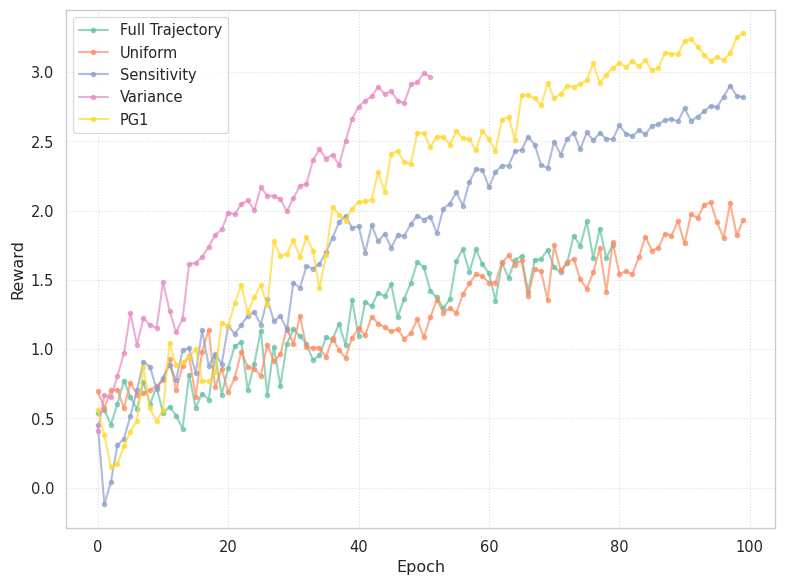

In [5]:
runs = {
    "Full Trajectory": [run_paths['morning-wave-19']],
    "Uniform": [run_paths['atomic-smoke-24']],
    "Sensitivity": [run_paths['royal-plasma-100']],
    "Variance": [run_paths['hopeful-cloud-103']],
    "SNR": [],
    "PG1": [run_paths['ruby-field-23']],
    }
metrics = {
    "train/reward": "Reward",
    # "train/ir_person": "ImageReward",
    # "train/aesthetics_score": "Aesthetic",
    # "train/sex_score_binary": "Gender"
    }
plot_wandb_metrics(runs, metrics)

# Sampled timestep distribution

In [6]:
def plot_overall_timestep_hist(run_path: str, show=True):
    """
    Given a W&B run path ("entity/project/run_id"),
    loads all timesteps/t=... metrics and plots a single aggregated histogram.

    Args:
        run_path (str): full run path, e.g. "amanda-mendes-cloudwalk/diffusion-finetune/abcd1234"
        show (bool): whether to display the matplotlib figure

    Returns:
        pd.Series: total counts per timestep
    """
    api = wandb.Api()
    run = api.run(run_path)

    # stream full history (efficiently)
    records = []
    for row in run.scan_history():  # no keys filter — wildcards not supported
        records.append(row)
    if not records:
        raise ValueError(f"No history found for run {run_path}")

    df = pd.DataFrame(records)

    # filter only the timestep columns
    ts_cols = [c for c in df.columns if c.startswith("timesteps/t=")]
    if not ts_cols:
        raise ValueError("No 'timesteps/t=' keys found in this run.")

    df = df[ts_cols]

    # sum counts across all steps
    timestep_sums = df.sum(axis=0)

    # parse timestep numbers
    timesteps = np.array([int(c.split("timesteps/t=")[1]) for c in timestep_sums.index])
    counts = timestep_sums.values
    idx = np.argsort(timesteps)
    timesteps, counts = timesteps[idx], counts[idx]

    # prepare result
    series = pd.Series(counts, index=timesteps, name="count")

    # plot
    plt.figure(figsize=(8, 4))
    plt.bar(timesteps, counts, width=1.0, color="C0")
    plt.xlabel("Timestep")
    plt.ylabel("Total count across training")
    plt.title(f"Timestep sampling histogram — {run.name}")
    plt.tight_layout()
    if show:
        plt.show()

    return series
